# 1. Import and Setup

In [1]:
# 1. Upgrade pip
# !pip install --upgrade pip

# 2. Install TensorFlow with CUDA support
# !pip install "tensorflow[and-cuda]==2.16.1"

# 3. Fix compatible dependencies
# !pip install numpy==1.26.4 opencv-python==4.11.0.86

In [2]:
# 4. Make sure Tensorflow, OpenCV, and Numpy is listed
!pip list

Package                   Version
------------------------- -----------
absl-py                   2.4.0
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
astunparse                1.6.3
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.4.22
cffi                      2.0.0
charset-normalizer        3.4.7
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
flatbuffers               25.12.19
fonttools                 4.62.1
fqdn                      1.5.1
gast                      0.7.0
google-pasta              0.2.0
grpcio         

In [3]:
import tensorflow as tf
import os

2026-04-26 23:20:46.783379: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-26 23:20:46.985688: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-26 23:20:48.482034: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
# Set GPU Memory Consumption Growth
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2026-04-26 23:20:50.404707: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-26 23:20:50.634234: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-26 23:20:50.634281: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 1.2 Remove Unreliable Images

In [5]:
import cv2
from PIL import Image
from matplotlib import pyplot as plt

In [6]:
data_dir = 'data'

In [7]:
image_exts = ['jpg', 'jpeg', 'png', 'bmp']

We want to make sure that we can load the image in OpenCV and the extension is a part of image_exts

In [8]:
# Get the image format 

def get_image_type(path):
    try:
        with Image.open(path) as img:
            return img.format.lower()
    except Exception:
        return None

In [9]:
# Read image with OpenCV

# try_img = cv2.imread(os.path.join('data', 'rice', 'Arborio', 'Arborio (1).jpg'))
# # plt.imshow(try_img)
# plt.imshow(cv2.cvtColor(try_img, cv2.COLOR_BGR2RGB))

In [10]:
for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)

    if not os.path.isdir(class_path):
        continue

    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)
        try:
            if not os.path.isfile(image_path):
                continue

            img = cv2.imread(image_path)
            tip = get_image_type(image_path)

            if tip not in image_exts or img is None:
                print('The image is not in the ext list {}'.format(image_path))
                os.remove(image_path)

        except Exception as e:
            print('Issue with image {}'.format(image_path))

## 1.3 Load Data

In [11]:
import numpy as np

In [12]:
# Preprocessing, building the data pipeline

data = tf.keras.utils.image_dataset_from_directory('data/rice', image_size=(250,250), class_names=['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag'])

Found 75000 files belonging to 5 classes.


2026-04-26 23:20:56.320953: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-26 23:20:56.321055: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-26 23:20:56.321076: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-26 23:20:56.523850: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-26 23:20:56.523920: I external/local_xla/xla/stream_executor

In [13]:
# Since the preprocessor is a generator, we can't access the data directly, hence we have to convert it into a numpy iterator

data_iterator = data.as_numpy_iterator()

In [14]:
batch = data_iterator.next()

In [15]:
len(batch)

2

In [16]:
# Represent image as numpy arrays

batch[0].shape

(32, 250, 250, 3)

In [17]:
# Image labels based on their class
# 0: Arborio, 1: Basmati, 2: Ipsala, 3: Jasmine, 4: Karacadag

batch[1]

array([1, 2, 0, 2, 3, 2, 4, 3, 4, 2, 2, 3, 3, 1, 0, 4, 2, 3, 4, 1, 1, 3,
       0, 2, 0, 1, 1, 2, 4, 1, 2, 1], dtype=int32)

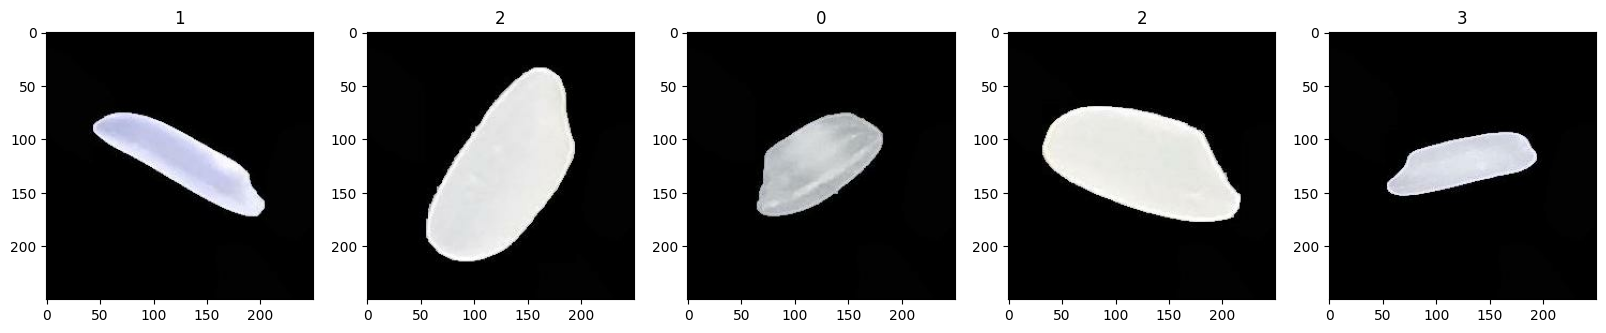

In [18]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])